# Synthetic Hierarchical Dataset Generation

Generate a large-scale hierarchical time series dataset using [signalfoundry](https://github.com/Nixtla/signalfoundry).

**Hierarchy** (4 levels):
- `growth_status` (5 series)
- `growth_status/country` (1,212 series)
- `growth_status/country/platform` (7,635 series)
- `growth_status/country/platform/age` (47,115 series)

**Total**: 55,967 series | 788 daily observations each (2024-01-01 to 2026-02-26) | ~44M rows

In [1]:
import numpy as np
import polars as pl
from signalfoundry.generators import DailyActiveUsersGenerator

## 1. Build Hierarchy Structure

We construct the 47,115 bottom-level combinations deterministically so that
`aggregate` produces exactly the specified series counts at each level.

In [2]:
rng = np.random.default_rng(42)

# Level 0: growth statuses
growth_statuses = ['retained', 'churned', 'new', 'reactivated', 'dormant']

# Level 1: countries (use ISO-style codes)
# 1212 (gs, country) pairs across 5 statuses -> [243, 243, 243, 242, 241] per status
all_countries = [f'C{i:03d}' for i in range(250)]
countries_per_gs = [243, 243, 243, 242, 241]

# Level 2: platforms
all_platforms = ['ios', 'android', 'web', 'windows', 'macos', 'linux', 'tablet', 'smart_tv']

# Level 3: age groups
all_ages = ['13-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']

print(f'Pool sizes: {len(all_countries)} countries, {len(all_platforms)} platforms, {len(all_ages)} age groups')

Pool sizes: 250 countries, 8 platforms, 8 age groups


In [3]:
# Build bottom-level combinations
# Strategy:
#   - For each growth_status, sample `countries_per_gs[i]` countries
#   - For each (gs, country), assign 6 or 7 platforms (363 get 7, 849 get 6 → total 7635)
#   - For each (gs, country, platform), assign 6 or 7 ages (1305 get 7, 6330 get 6 → total 47115)

records = []
pair_idx = 0      # tracks (gs, country) pairs for platform assignment
triple_idx = 0    # tracks (gs, country, platform) triples for age assignment

# Pre-determine which pairs get 7 platforms (first 363) and which get 6
n_pairs_with_7 = 363   # 363*7 + 849*6 = 7635
# Pre-determine which triples get 7 ages (first 1305) and which get 6
n_triples_with_7 = 1305  # 1305*7 + 6330*6 = 47115

for gs_i, gs in enumerate(growth_statuses):
    n_countries = countries_per_gs[gs_i]
    countries = rng.choice(all_countries, size=n_countries, replace=False)
    
    for country in countries:
        # Assign platforms
        n_platforms = 7 if pair_idx < n_pairs_with_7 else 6
        platforms = rng.choice(all_platforms, size=n_platforms, replace=False)
        pair_idx += 1
        
        for platform in platforms:
            # Assign age groups
            n_ages = 7 if triple_idx < n_triples_with_7 else 6
            ages = rng.choice(all_ages, size=n_ages, replace=False)
            triple_idx += 1
            
            for age in ages:
                records.append({
                    'growth_status': gs,
                    'country': country,
                    'platform': platform,
                    'age': age,
                })

hierarchy_df = pl.DataFrame(records)
print(f'Bottom-level series: {len(hierarchy_df)}')
print(f'Unique (gs): {hierarchy_df["growth_status"].n_unique()}')
print(f'Unique (gs, country): {hierarchy_df.group_by(["growth_status", "country"]).n_unique().shape[0]}')
print(f'Unique (gs, country, platform): {hierarchy_df.group_by(["growth_status", "country", "platform"]).n_unique().shape[0]}')

Bottom-level series: 47115
Unique (gs): 5
Unique (gs, country): 1212
Unique (gs, country, platform): 7635


## 2. Generate Time Series with SignalFoundry

We use `DailyActiveUsersGenerator` with different parameters per growth status to
produce realistic patterns. The `event` column indicates viral moments — the
exogenous feature mentioned in the spec.

In [4]:
# Generator config per growth status
# Different base_users and growth_rates to reflect each segment's behavior
generator_configs = {
    'retained':    {'base_users': 5000,  'growth_rate':  0.0003, 'app_type': 'consumer'},
    'churned':     {'base_users': 3000,  'growth_rate': -0.0010, 'app_type': 'consumer'},
    'new':         {'base_users': 1000,  'growth_rate':  0.0020, 'app_type': 'consumer'},
    'reactivated': {'base_users': 2000,  'growth_rate':  0.0005, 'app_type': 'consumer'},
    'dormant':     {'base_users': 500,   'growth_rate': -0.0005, 'app_type': 'consumer'},
}

In [ ]:
%%time

dfs = []
series_offset = 0

for gs in growth_statuses:
    mask = hierarchy_df['growth_status'] == gs
    n_series = mask.sum()
    cfg = generator_configs[gs]
    
    gen = DailyActiveUsersGenerator(
        min_length=788,
        max_length=788,
        freq='1d',
        start_datetime='2024-01-01 00:00:00',
        seed=hash(gs) % (2**31),
        base_users=cfg['base_users'],
        growth_rate=cfg['growth_rate'],
        app_type=cfg['app_type'],
        event_probability=0.03,
        event_impact_min=1.3,
        event_impact_max=2.5,
        event_decay_rate=0.15,
        noise_std=0.08,
        backend='polars',
    )
    
    df = gen.generate(n_series=n_series, start_id=series_offset)
    dfs.append(df)
    series_offset += n_series
    print(f'{gs}: {n_series:,} series, {len(df):,} rows')

ts_df = pl.concat(dfs)
print(f'\nTotal generated: {len(ts_df):,} rows')

retained: 11,511 series, 9,070,668 rows
churned: 9,468 series, 7,460,784 rows
new: 8,748 series, 6,893,424 rows
reactivated: 8,712 series, 6,865,056 rows
dormant: 8,676 series, 6,836,688 rows

Total generated: 37,126,620 rows
CPU times: user 6.6 s, sys: 992 ms, total: 7.59 s
Wall time: 7.59 s


## 3. Attach Hierarchy Columns

In [6]:
# Map series_id -> hierarchy columns
hierarchy_df = hierarchy_df.with_columns(pl.arange(0, pl.len()).alias('unique_id'))
hierarchy_df = hierarchy_df.with_columns(pl.format("series_{}", pl.col("unique_id")).alias("unique_id"))

# Merge hierarchy info onto the time series
Y_df = ts_df.join(hierarchy_df, on='unique_id', how='left')
Y_df = Y_df.drop('unique_id')

print(f'Shape: {Y_df.shape}')
print(f'Memory: {Y_df.estimated_size() / 1e9:.2f} GB')
Y_df.head()

Shape: (37126620, 7)
Memory: 1.54 GB


ds,y,event,growth_status,country,platform,age
datetime[ns],f64,i32,str,str,str,str
2024-01-01 00:00:00,5314.784414,0,"""retained""","""C232""","""smart_tv""","""13-17"""
2024-01-02 00:00:00,5108.466854,0,"""retained""","""C232""","""smart_tv""","""13-17"""
2024-01-03 00:00:00,5466.225655,0,"""retained""","""C232""","""smart_tv""","""13-17"""
2024-01-04 00:00:00,8244.715142,1,"""retained""","""C232""","""smart_tv""","""13-17"""
2024-01-05 00:00:00,8733.617823,0,"""retained""","""C232""","""smart_tv""","""13-17"""


## 4. Verify Hierarchy with `aggregate`

In [7]:
from hierarchicalforecast.utils import aggregate

spec = [
    ['growth_status'],
    ['growth_status', 'country'],
    ['growth_status', 'country', 'platform'],
    ['growth_status', 'country', 'platform', 'age'],
]

Y_df_cs, S_df, tags = aggregate(Y_df, spec)

In [8]:
# Verify counts
for level_name, level_ids in tags.items():
    print(f'{level_name}: {len(level_ids):,} series')

print(f'\nTotal series: {S_df.shape[0]:,}')
print(f'Bottom series: {S_df.shape[1]:,}')
print(f'Total rows: {len(Y_df_cs):,}')
print(f'Obs per series: {len(Y_df_cs) / S_df.shape[0]:.0f}')

growth_status: 5 series
growth_status/country: 1,212 series
growth_status/country/platform: 7,635 series
growth_status/country/platform/age: 47,115 series

Total series: 55,967
Bottom series: 47,116
Total rows: 44,101,996
Obs per series: 788


### 4a. Temporal aggregation

In [9]:
spec_temporal = {"1w": 7, "1d": 1}

In [10]:
horizon = 364

Y_test_df_cs = Y_df_cs.group_by('unique_id').tail(horizon)
Y_train_df_cs = Y_df_cs.filter(pl.col("ds") < Y_test_df_cs['ds'].min())

In [11]:
from hierarchicalforecast.utils import aggregate_temporal

Y_train_df_te, S_train_df_te, tags_te_train = aggregate_temporal(df=Y_train_df_cs, spec=spec_temporal)
Y_test_df_te, S_test_df_te, tags_te_test = aggregate_temporal(df=Y_test_df_cs, spec=spec_temporal)

print(f'Temporal hierarchy: {S_test_df_te.shape[0]} levels, {S_test_df_te.shape[1] - 1} bottom periods')

Temporal hierarchy: 416 levels, 364 bottom periods


## 5. Feature Engineering from Viral Events

The `event` column flags viral moments. We can engineer features such as:
- `is_viral`: binary indicator (same as `event`)
- `days_since_viral`: days since the last viral event
- `viral_rolling_7d`: count of viral events in the past 7 days

In [12]:
# Example feature engineering on a small subset
# sample_ids = Y_df.groupby('growth_status').apply(
#     lambda x: x[['growth_status', 'country', 'platform', 'age']].drop_duplicates().head(1)
# ).reset_index(drop=True)

# sample = Y_df.merge(sample_ids, on=['growth_status', 'country', 'platform', 'age'])
# sample['unique_id'] = (
#     sample['growth_status'] + '/' + sample['country'] + '/' +
#     sample['platform'] + '/' + sample['age']
# )

# # Days since last viral event
# sample = sample.sort_values(['unique_id', 'ds'])
# sample['is_viral'] = sample['event']
# sample['viral_rolling_7d'] = (
#     sample.groupby('unique_id')['event']
#     .transform(lambda x: x.rolling(7, min_periods=1).sum())
# )

# sample[sample['unique_id'] == sample['unique_id'].iloc[0]].head(15)

In [13]:
# Save to parquet for downstream use
# Y_df.to_parquet('synthetic_hierarchical_dataset.parquet', index=False)

## 6. Visualize the Hierarchy

Plot sample series at each hierarchical level using `utilsforecast.plot_series`.

In [14]:
from utilsforecast.plotting import plot_series

### Top level: growth_status (5 series)

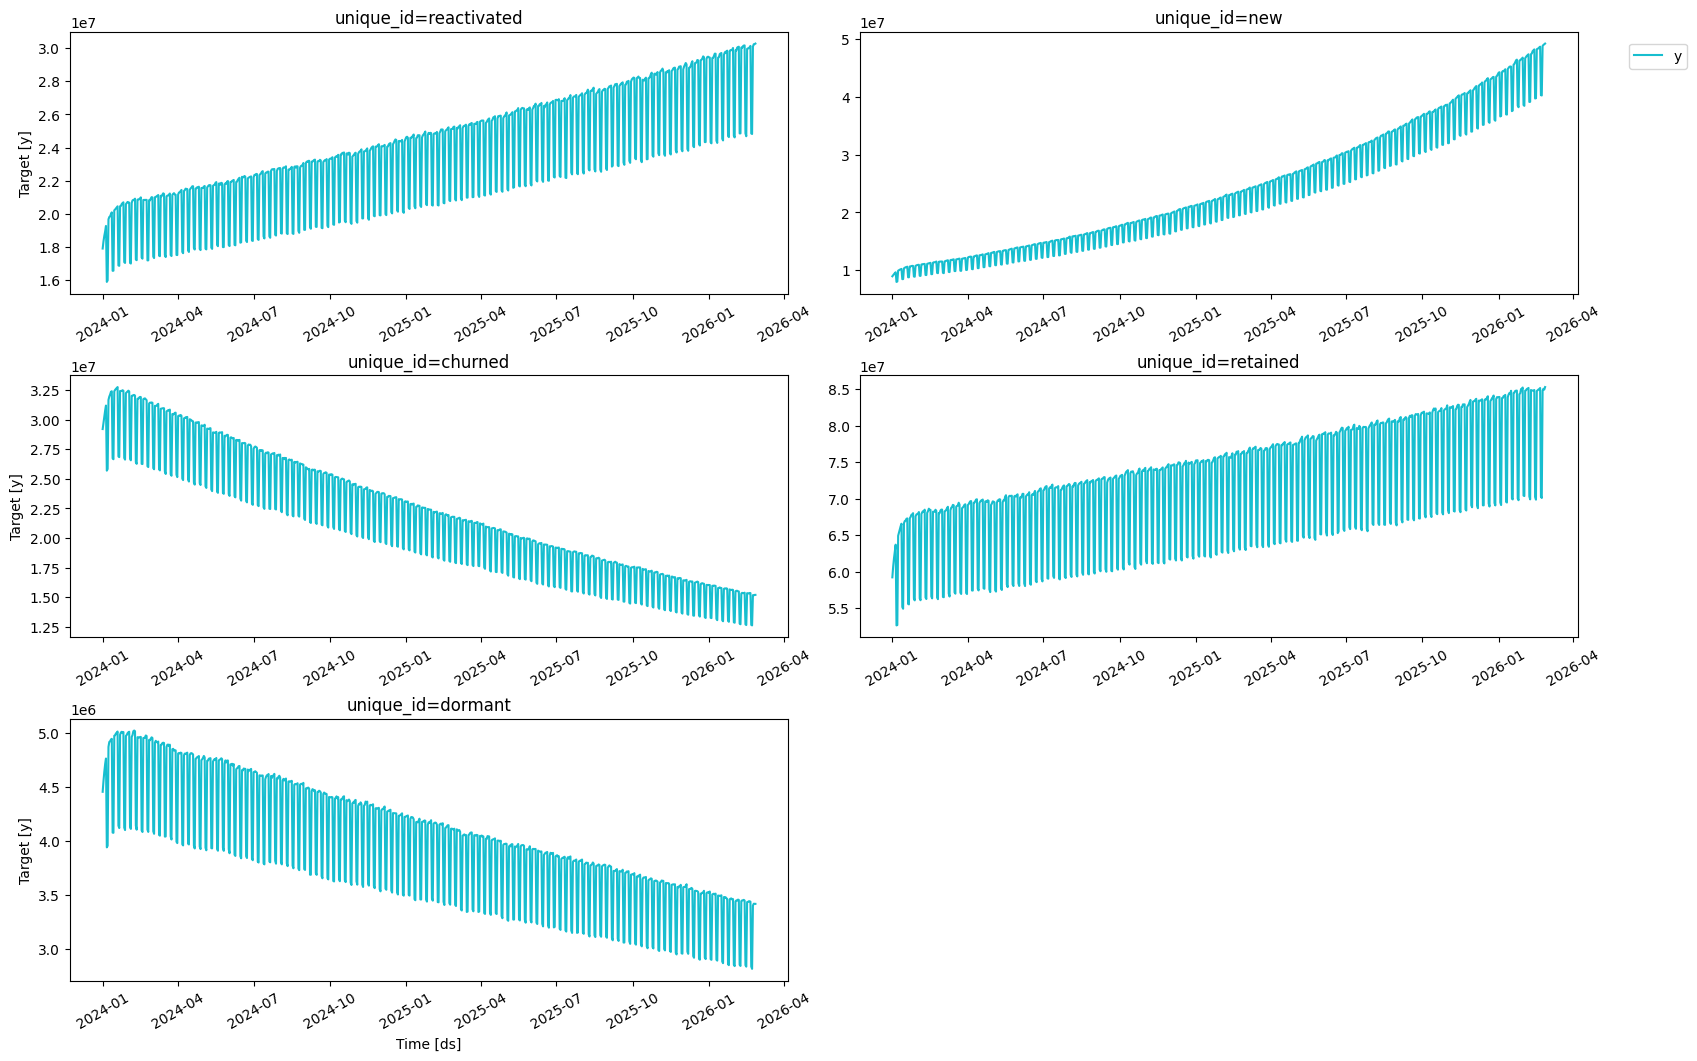

In [15]:
top_level_ids = tags['growth_status']
plot_series(Y_df_cs.filter(pl.col('unique_id').is_in(top_level_ids)), max_ids=5, plot_random=False)

### Second level: growth_status/country (sample of 1,212 series)

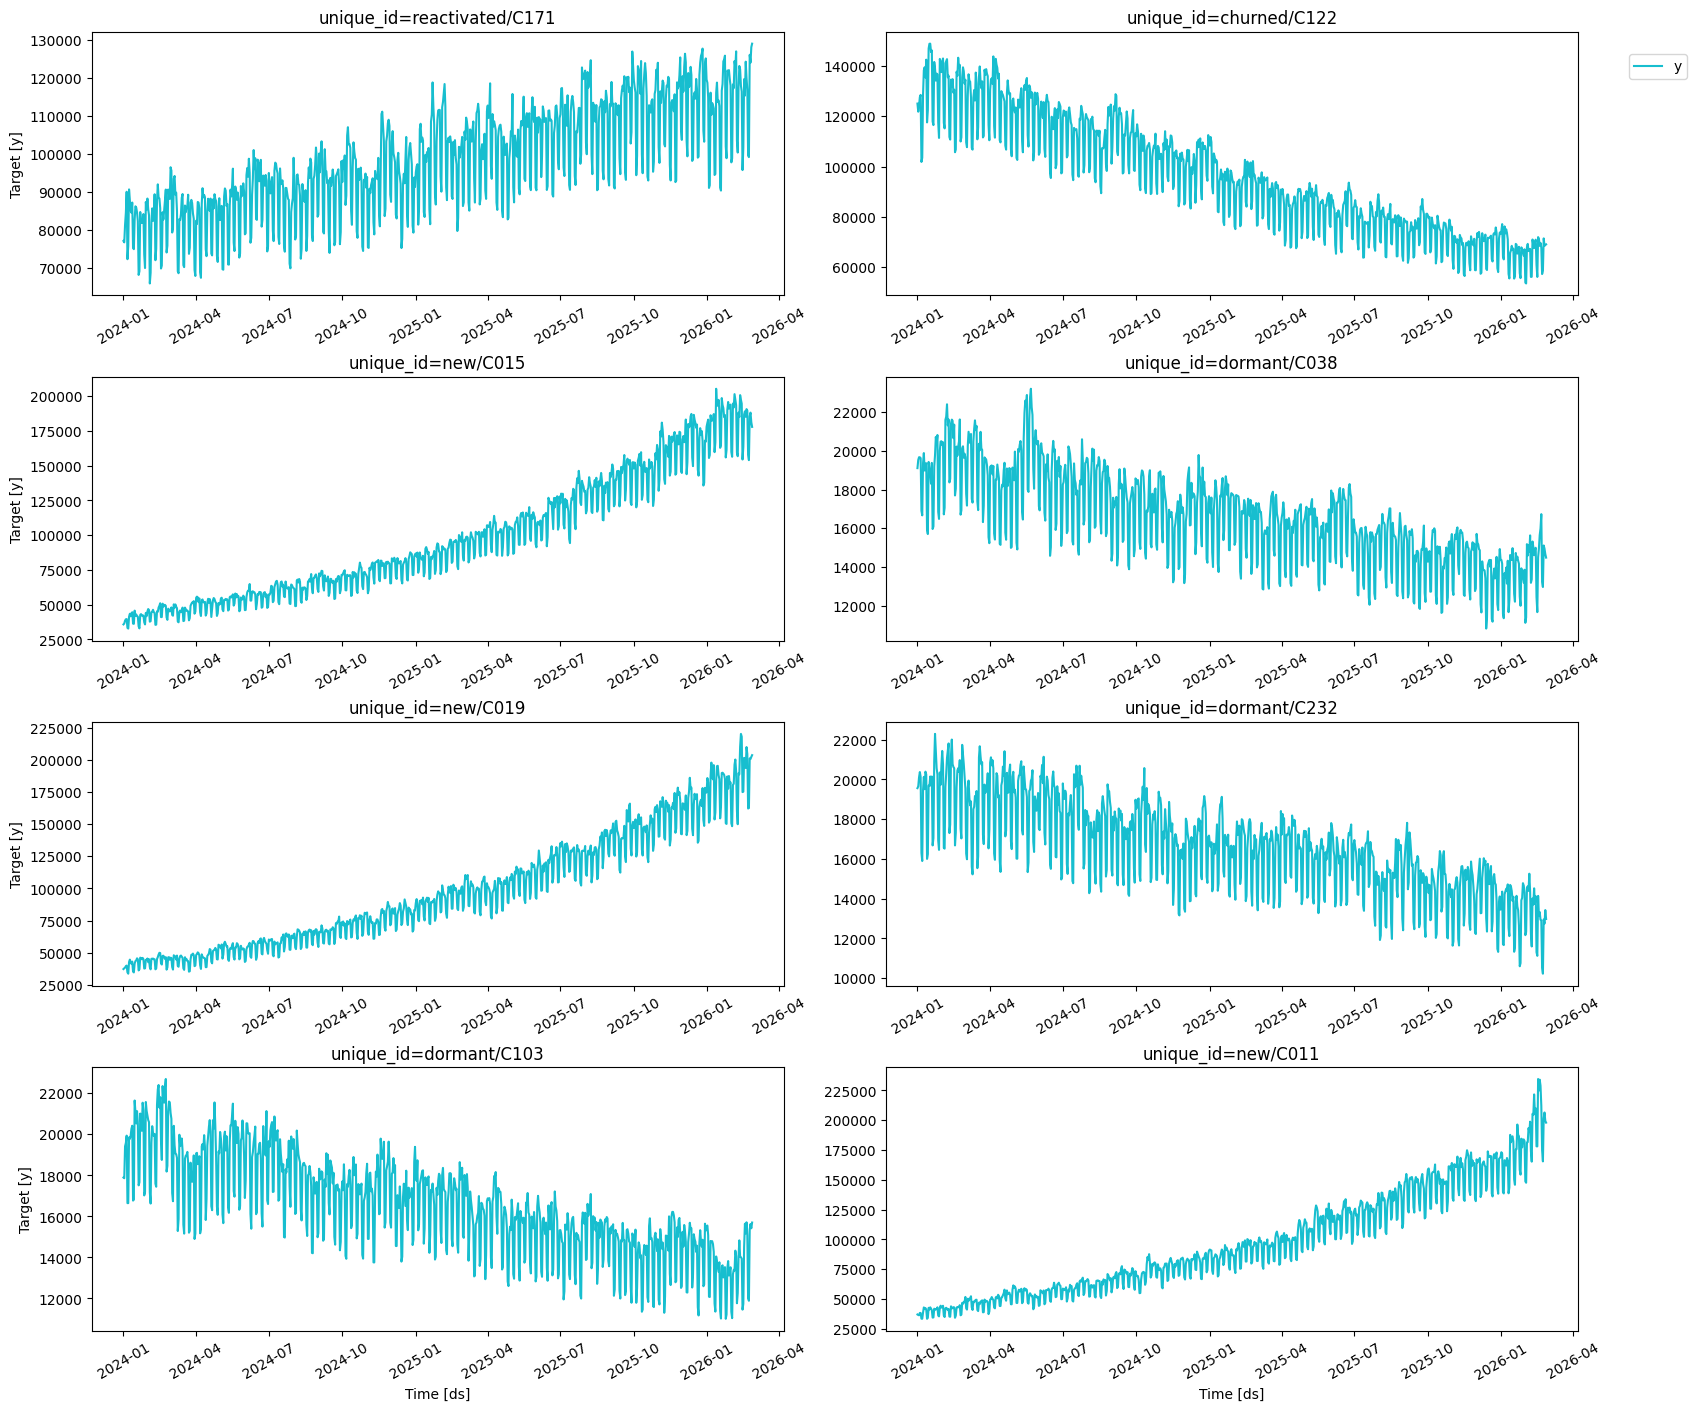

In [16]:
country_level_ids = tags['growth_status/country']
plot_series(Y_df_cs.filter(pl.col('unique_id').is_in(country_level_ids)), max_ids=8, seed=42)

### Third level: growth_status/country/platform (sample of 7,635 series)

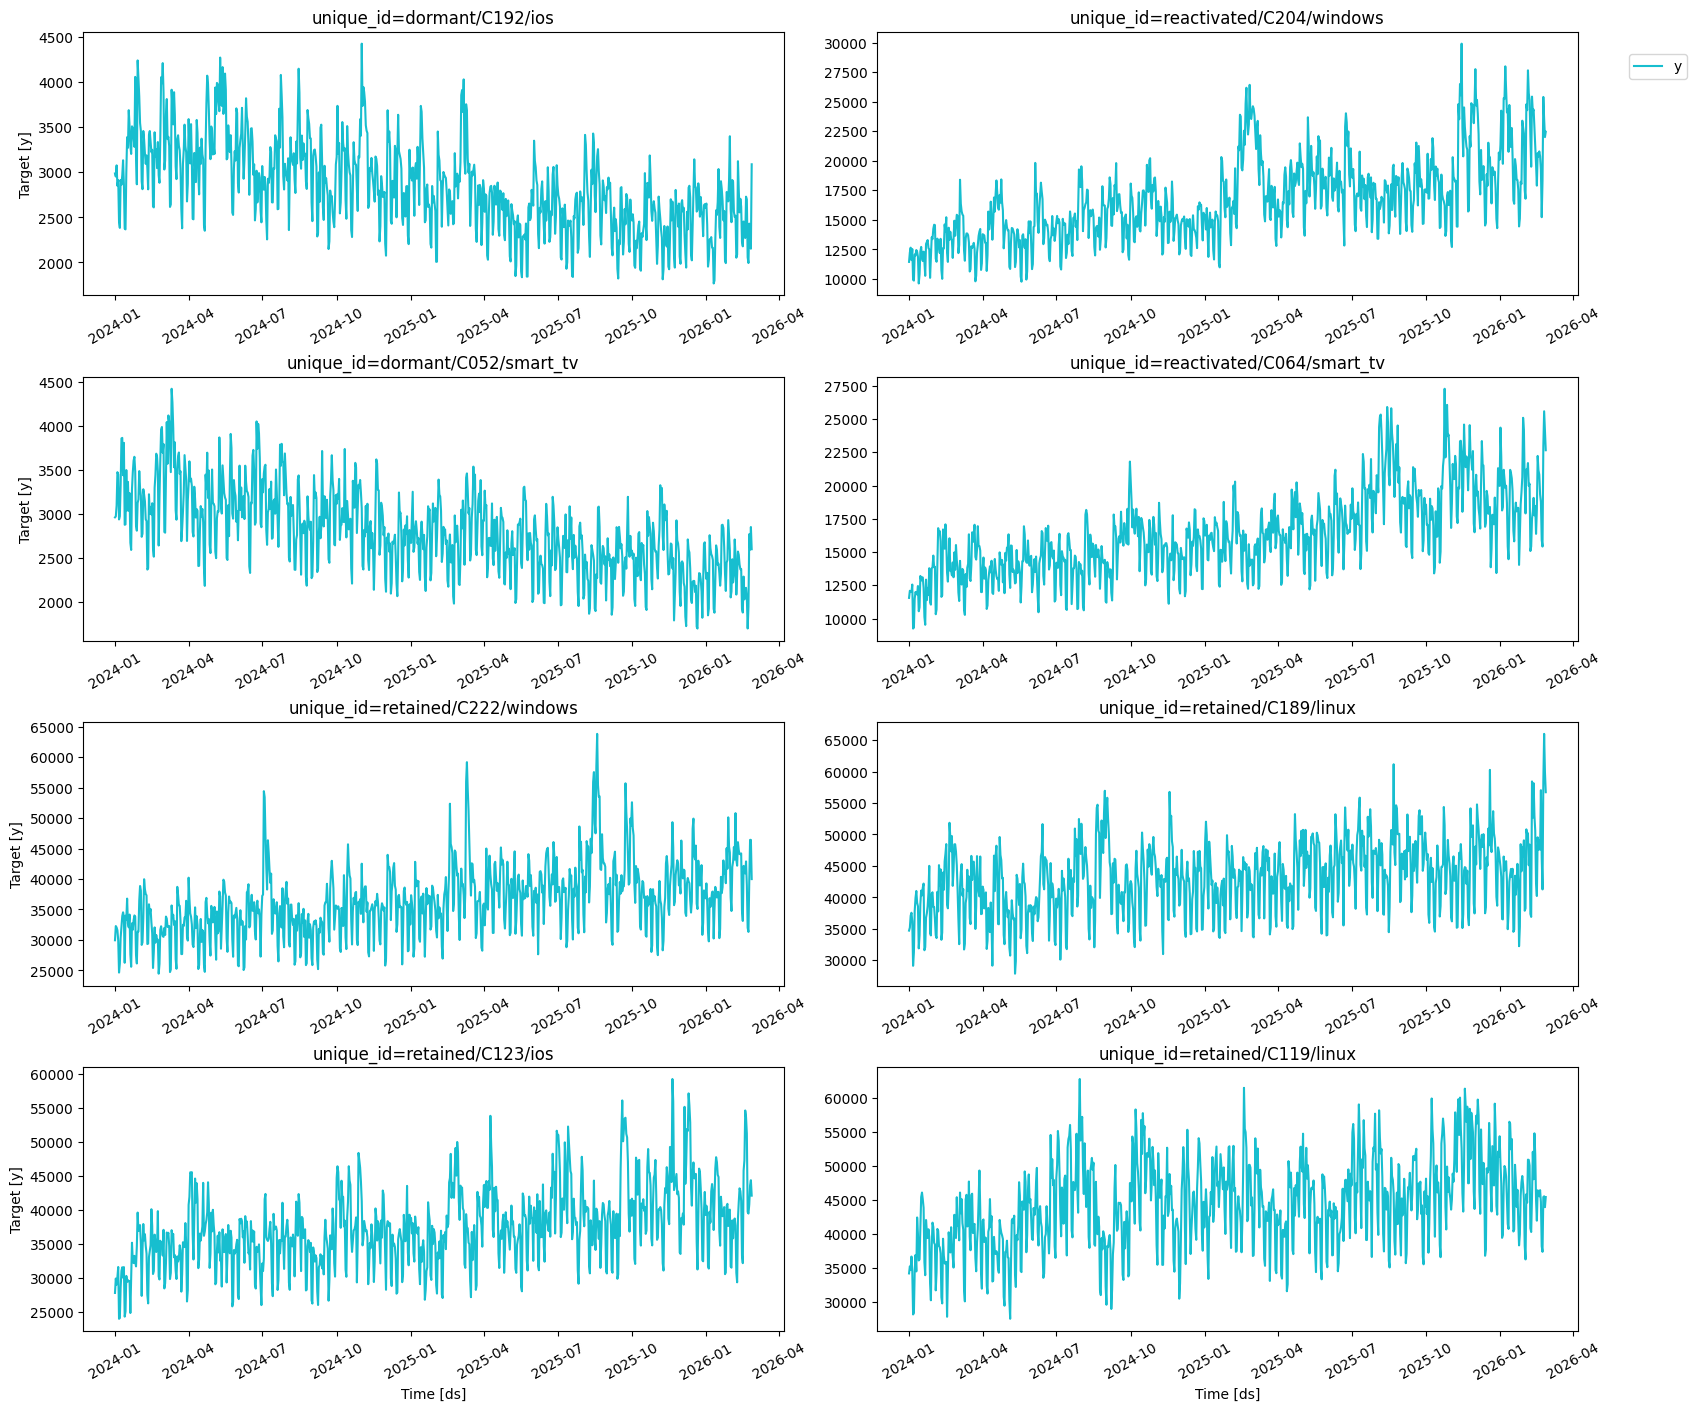

In [17]:
platform_level_ids = tags['growth_status/country/platform']
plot_series(Y_df_cs.filter(pl.col('unique_id').is_in(platform_level_ids)), max_ids=8, seed=42)

### Bottom level: growth_status/country/platform/age (sample of 47,115 series)

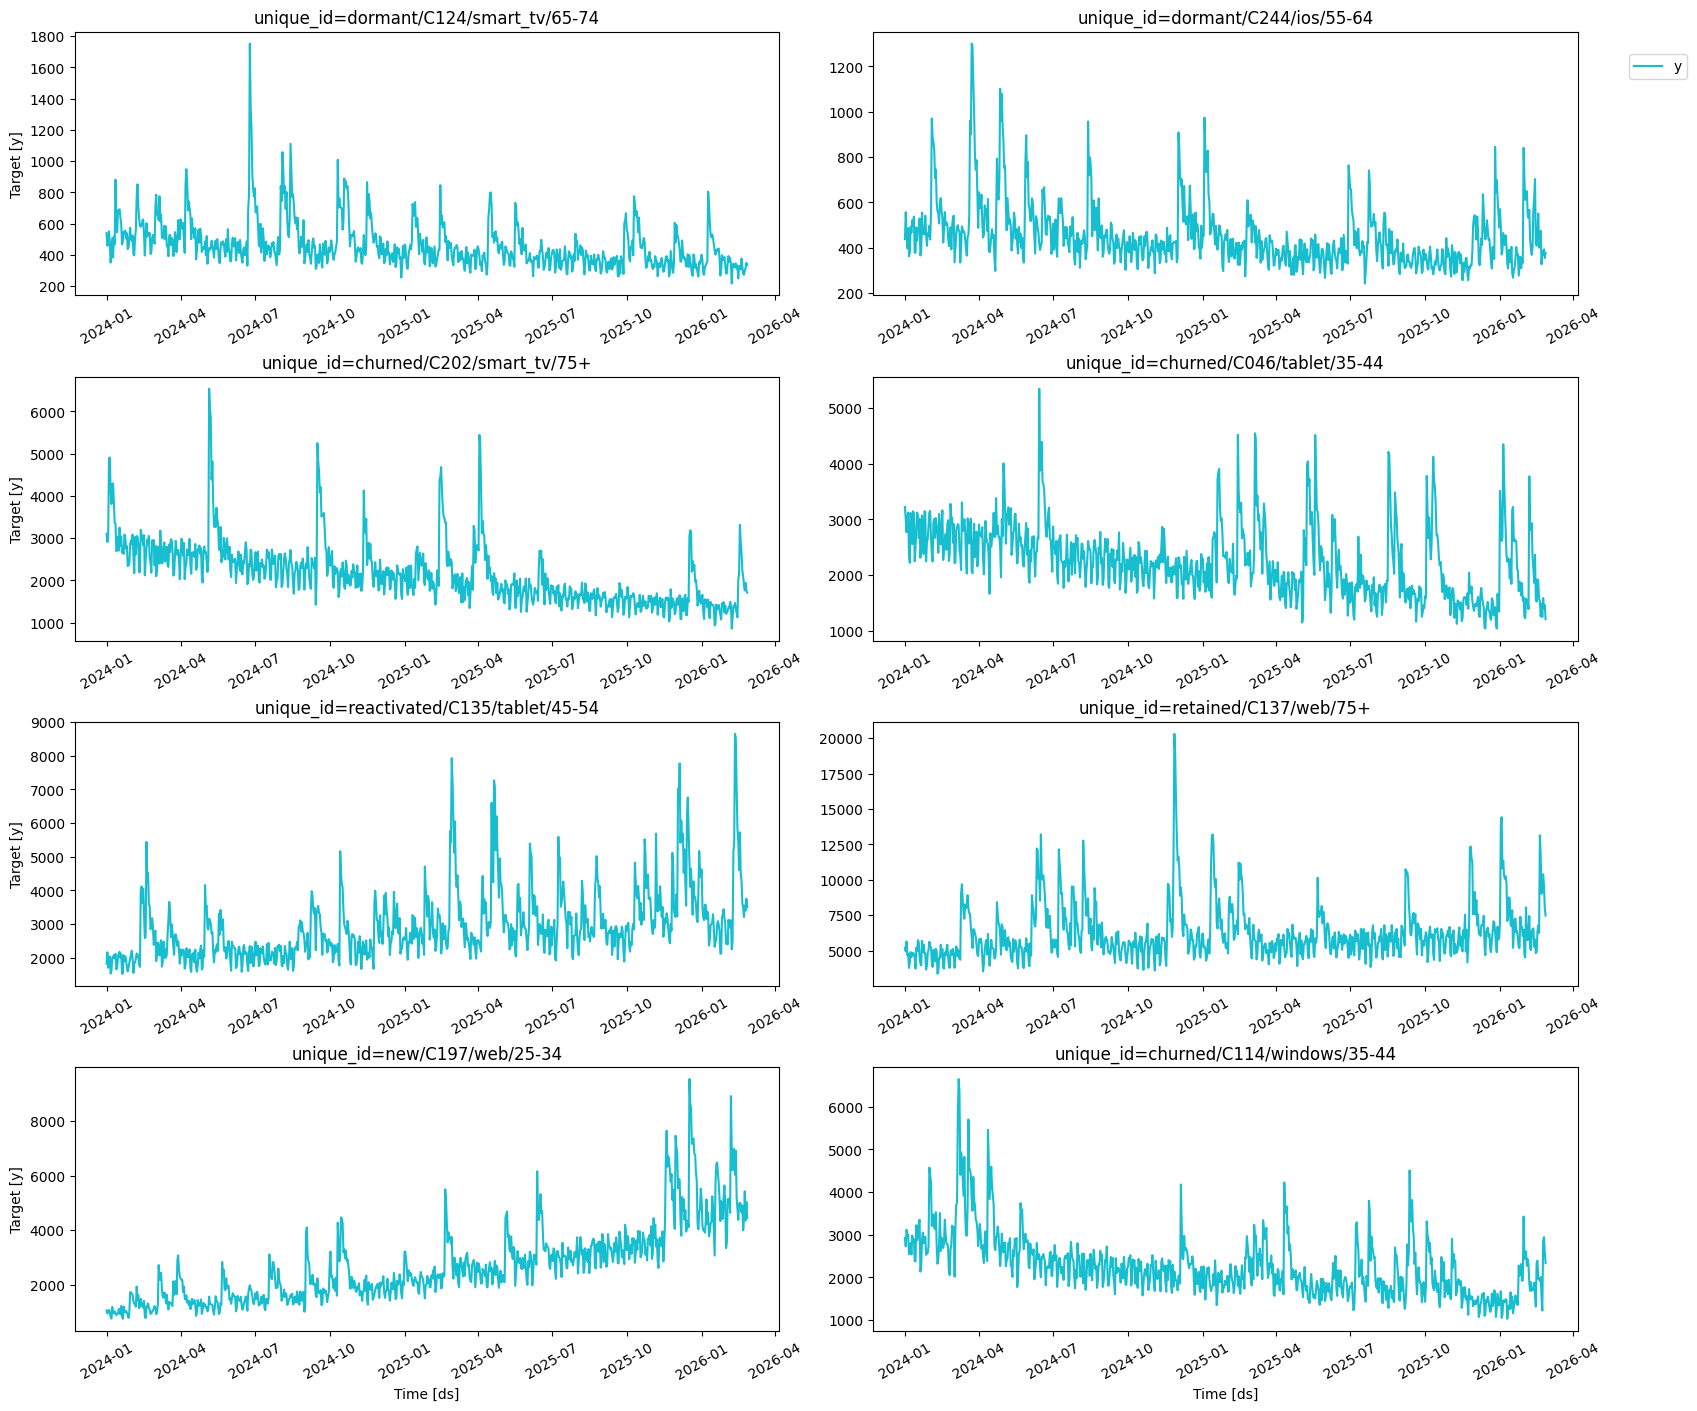

In [18]:
bottom_level_ids = tags['growth_status/country/platform/age']
plot_series(Y_df_cs.filter(pl.col('unique_id').is_in(bottom_level_ids)), max_ids=8, seed=42)

## 7. Hierarchical forecasting + reconciliation

We create:
- Cross-sectional forecasts
- Daily and weekly forecasts (364 days and 52 weeks)

We then reconcile these forecasts using cross-temporal reconciliation

In [19]:
from nixtla import NixtlaClient

client = NixtlaClient(base_url="http://localhost:8000")

In [20]:
Y_hat_dfs_te = []
id_cols = ["unique_id", "temporal_id", "ds", "y"]
# We will train a model for each temporal level
for level, temporal_ids_train in tags_te_train.items():
    # Filter the data for the level
    Y_level_train = Y_train_df_te.filter(pl.col("temporal_id").is_in(temporal_ids_train))
    temporal_ids_test = tags_te_test[level]
    Y_level_test = Y_test_df_te.filter(pl.col("temporal_id").is_in(temporal_ids_test))
    # For each temporal level we have a different frequency and forecast horizon
    horizon_level = Y_level_test["ds"].n_unique()
    # Train a model and create forecasts
    Y_hat_df_te_level = client.forecast(df=Y_level_train[["ds", "unique_id", "y"]], h=horizon_level, freq=level)
    # Add the test set to the forecast
    Y_hat_df_te_level = Y_hat_df_te_level.join(Y_level_test, on=["ds", "unique_id"], how="left")
    # Put cols in the right order (for readability)
    Y_hat_cols = id_cols + [col for col in Y_hat_df_te_level.columns if col not in id_cols]
    Y_hat_df_te_level = Y_hat_df_te_level[Y_hat_cols]
    # Append the forecast to the list
    Y_hat_dfs_te.append(Y_hat_df_te_level)

Y_hat_df_te = pl.concat(Y_hat_dfs_te)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...


expected_ids_times: shape: (3_358_020, 2)
┌───────────────────────────┬─────────────────────┐
│ unique_id                 ┆ ds                  │
│ ---                       ┆ ---                 │
│ str                       ┆ datetime[ns]        │
╞═══════════════════════════╪═════════════════════╡
│ churned                   ┆ 2024-01-07 00:00:00 │
│ churned                   ┆ 2024-01-14 00:00:00 │
│ churned                   ┆ 2024-01-21 00:00:00 │
│ churned                   ┆ 2024-01-28 00:00:00 │
│ churned                   ┆ 2024-02-04 00:00:00 │
│ …                         ┆ …                   │
│ retained/C249/windows/75+ ┆ 2025-01-26 00:00:00 │
│ retained/C249/windows/75+ ┆ 2025-02-02 00:00:00 │
│ retained/C249/windows/75+ ┆ 2025-02-09 00:00:00 │
│ retained/C249/windows/75+ ┆ 2025-02-16 00:00:00 │
│ retained/C249/windows/75+ ┆ 2025-02-23 00:00:00 │
└───────────────────────────┴─────────────────────┘
len(df): 3413987


INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...


expected_ids_times: shape: (23_730_008, 2)
┌───────────────────────────┬─────────────────────┐
│ unique_id                 ┆ ds                  │
│ ---                       ┆ ---                 │
│ str                       ┆ datetime[ns]        │
╞═══════════════════════════╪═════════════════════╡
│ churned                   ┆ 2024-01-01 00:00:00 │
│ churned                   ┆ 2024-01-02 00:00:00 │
│ churned                   ┆ 2024-01-03 00:00:00 │
│ churned                   ┆ 2024-01-04 00:00:00 │
│ churned                   ┆ 2024-01-05 00:00:00 │
│ …                         ┆ …                   │
│ retained/C249/windows/75+ ┆ 2025-02-23 00:00:00 │
│ retained/C249/windows/75+ ┆ 2025-02-24 00:00:00 │
│ retained/C249/windows/75+ ┆ 2025-02-25 00:00:00 │
│ retained/C249/windows/75+ ┆ 2025-02-26 00:00:00 │
│ retained/C249/windows/75+ ┆ 2025-02-27 00:00:00 │
└───────────────────────────┴─────────────────────┘
len(df): 23730008


INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


In [21]:
from hierarchicalforecast.methods import BottomUp, MinTrace, TopDown, TopDownSparse
from hierarchicalforecast.core import HierarchicalReconciliation

In [22]:
# Methods that don't require residuals (no Y_df needed)
reconcilers_no_insample = [
    BottomUp(),
    # MinTrace(method='ols'),
    # MinTrace(method='wls_struct'),
    TopDownSparse(method='forecast_proportions'),
    # MinTrace(method='csstr'),
    # MinTrace(method='testr'),
]

hrec = HierarchicalReconciliation(reconcilers=reconcilers_no_insample)
Y_rec_ct_no_insample = hrec.reconcile(
    Y_hat_df=Y_hat_df_te,
    S_df=S_test_df_te,  # This is ignored; S_ct is built from S_cs_df and S_te_df
    tags=tags_te_test,
    temporal=True,
)
print(f'Reconciled (no insample): {Y_rec_ct_no_insample.shape}')
Y_rec_ct_no_insample.head()

Reconciled (no insample): (23282272, 7)


unique_id,temporal_id,ds,y,TimeGPT,TimeGPT/BottomUp,TimeGPT/TopDownSparse_method-forecast_proportions
str,str,datetime[ns],f64,f64,f64,f64
"""reactivated/C241/ios/45-54""","""1w-1""",2025-03-06 00:00:00,16103.639763,13173.394,2.1313e7,13173.394
"""retained/C216/tablet""","""1w-1""",2025-03-06 00:00:00,309671.237264,222001.2,20213.7603,222001.2
"""churned/C046/linux/55-64""","""1w-1""",2025-03-06 00:00:00,12700.821254,11491.953,24989.2998,11491.953
"""new/C203/ios/18-24""","""1w-1""",2025-03-06 00:00:00,21831.024549,12575.099,66002.2685,12575.099
"""churned/C046/linux/75+""","""1w-1""",2025-03-06 00:00:00,16879.417785,10757.762,38660.146,10757.762


## 4. Evaluation 

The `HierarchicalForecast` package includes the `evaluate` function to evaluate the different hierarchies.

In [23]:
from hierarchicalforecast.evaluation import evaluate
from utilsforecast.losses import rmse

In [24]:
evaluation = evaluate(df = Y_rec_ct_no_insample.drop('temporal_id'),
                      tags = tags,
                      metrics = [rmse])

In [25]:
evaluation

level,metric,TimeGPT,TimeGPT/BottomUp,TimeGPT/TopDownSparse_method-forecast_proportions
str,str,f64,f64,f64
"""growth_status""","""rmse""",2.2844e7,7.8517e7,3.7606e7
"""growth_status/country""","""rmse""",94716.740461,336844.870742,372667.385607
"""growth_status/country/platform""","""rmse""",15110.667318,84005.400729,136508.546442
"""growth_status/country/platform…","""rmse""",3076.395936,67002.342115,35035.431626
"""Overall""","""rmse""",8743.18302,82174.078555,59546.552857
